# Nutrition5k: обучение CatBoost для оценки массы

Ноутбук строит табличные признаки из RGB-изображения блюда, пиксельной маски YOLO-сегментации и карты глубины из `depth_estimation`, затем обучает `CatBoostRegressor` на целевой массе из `dish_nutrition_values.csv`.

In [3]:
!pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Found existing installation: torch 2.9.0
Uninstalling torch-2.9.0:
  Successfully uninstalled torch-2.9.0
Found existing installation: torchvision 0.24.0
Uninstalling torchvision-0.24.0:
  Successfully uninstalled torchvision-0.24.0


You can safely remove it manually.
You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached torch-2.12.0%2Bcu130-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0%2Bcu130-cp314-cp314-win_amd64.whl.metadata (5.6 kB)
Using cached torch-2.12.0%2Bcu130-cp314-cp314-win_amd64.whl (1933.5 MB)
Using cached torchvision-0.27.0%2Bcu130-cp314-cp314-win_amd64.whl (9.1 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
depth-estimation 0.1.1 requires torch==2.9.0, but you have torch 2.12.0+cu130 which is incompatible.


In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA not available")

13.0
True
NVIDIA GeForce RTX 5070 Ti


In [3]:
from pathlib import Path
import json
import math
import os
import sys
import time
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool
from ultralytics import YOLO

c:\training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "mass_estimation").exists() and (path / "DepthModule").exists()
)

MASS_DIR = PROJECT_ROOT / "mass_estimation"
RESULTS_DIR = MASS_DIR / "depth-large-results"
DEPTH_DIR = PROJECT_ROOT / "DepthModule"
YOLO_MODEL_PATH = PROJECT_ROOT / "models" / "yolo_food_seg.pt"

NUTRITION_CSV = MASS_DIR / "dish_nutrition_values.csv"
OVERHEAD_DIR = MASS_DIR / "imagery" / "realsense_overhead"

FEATURES_CSV = RESULTS_DIR / "catboost_mass_features.csv"
MODEL_PATH = RESULTS_DIR / "catboost_food_mass.cbm"
METRICS_PATH = RESULTS_DIR / "catboost_food_mass_metrics.json"

assert MASS_DIR.exists(), MASS_DIR
assert RESULTS_DIR.exists(), RESULTS_DIR
assert DEPTH_DIR.exists(), DEPTH_DIR
assert YOLO_MODEL_PATH.exists(), YOLO_MODEL_PATH
assert NUTRITION_CSV.exists(), NUTRITION_CSV
assert OVERHEAD_DIR.exists(), OVERHEAD_DIR

if str(DEPTH_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_DIR))

from depth_module import DepthEstimationModule

PROJECT_ROOT

WindowsPath('C:/training')

In [ ]:
RANDOM_STATE = 451
MAX_DISHES = None
RESUME_FEATURE_CACHE = True
USE_EXISTING_DEPTH_RAW = False

YOLO_CONF = 0.25
YOLO_IMGSZ = 640
CACHE_EVERY_N_ROWS = 25

CATBOOST_PARAMS = dict(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=3000,
    learning_rate=0.03,
    depth=12,
    l2_leaf_reg=6,
    random_seed=RANDOM_STATE,
    od_type="Iter",
    od_wait=150,
    verbose=100,

    task_type="GPU",
    devices="0"
)

In [6]:
labels = pd.read_csv(NUTRITION_CSV)
labels = labels[["dish_id", "mass"]].dropna()
labels["rgb_path"] = labels["dish_id"].apply(lambda dish_id: OVERHEAD_DIR / dish_id / "rgb.png")
labels["depth_raw_path"] = labels["dish_id"].apply(lambda dish_id: OVERHEAD_DIR / dish_id / "depth_raw.png")
labels = labels[labels["rgb_path"].map(lambda p: p.exists())].copy()
labels = labels.sort_values("dish_id").reset_index(drop=True)

if MAX_DISHES is not None:
    labels = labels.head(MAX_DISHES).copy()

print(f"Rows with rgb.png and mass target: {len(labels):,}")
labels.head()

Rows with rgb.png and mass target: 3,244


,dish_id,mass,rgb_path,depth_raw_path
0,dish_1556572657,36.0,C:\training\mass_estimation\imagery\realsense_...,C:\training\mass_estimation\imagery\realsense_...
1,dish_1556573514,23.0,C:\training\mass_estimation\imagery\realsense_...,C:\training\mass_estimation\imagery\realsense_...
2,dish_1556575014,62.0,C:\training\mass_estimation\imagery\realsense_...,C:\training\mass_estimation\imagery\realsense_...
3,dish_1556575083,64.0,C:\training\mass_estimation\imagery\realsense_...,C:\training\mass_estimation\imagery\realsense_...
4,dish_1556575124,28.0,C:\training\mass_estimation\imagery\realsense_...,C:\training\mass_estimation\imagery\realsense_...


## Извлечение маски и карты глубины

Для одного блюда объединяются все найденные YOLO-маски еды. Категориальный признак `food_class` берется из самой большой маски; если на блюде несколько классов, число масок и confidence также идут в признаки.

In [7]:
def resize_nearest(mask: np.ndarray, shape_hw: Tuple[int, int]) -> np.ndarray:
    if mask.shape[:2] == shape_hw:
        return mask
    return cv2.resize(mask.astype(np.uint8), (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST).astype(bool)


def resize_depth(depth: np.ndarray, shape_hw: Tuple[int, int]) -> np.ndarray:
    depth = np.asarray(depth, dtype=np.float32)
    if depth.shape[:2] == shape_hw:
        return depth
    return cv2.resize(depth, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_LINEAR)


def predict_union_mask(seg_model: YOLO, image: Image.Image) -> Tuple[np.ndarray, Dict[str, float]]:
    image_np = np.array(image.convert("RGB"))
    h, w = image_np.shape[:2]
    result = seg_model.predict(image_np, retina_masks=True, conf=YOLO_CONF, imgsz=YOLO_IMGSZ, verbose=False)[0]

    if result.masks is None or result.boxes is None or len(result.boxes) == 0:
        return np.zeros((h, w), dtype=bool), {
            "food_class": "unknown",
            "n_masks": 0,
            "seg_conf_mean": 0.0,
            "seg_conf_max": 0.0,
            "dominant_mask_area_px": 0,
        }

    masks = result.masks.data.cpu().numpy() > 0.5
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy().astype(float)

    resized_masks = [resize_nearest(mask, (h, w)) for mask in masks]
    areas = np.array([int(mask.sum()) for mask in resized_masks])
    keep = areas > 0
    if not keep.any():
        return np.zeros((h, w), dtype=bool), {
            "food_class": "unknown",
            "n_masks": 0,
            "seg_conf_mean": 0.0,
            "seg_conf_max": 0.0,
            "dominant_mask_area_px": 0,
        }

    resized_masks = [m for m, k in zip(resized_masks, keep) if k]
    classes = classes[keep]
    confs = confs[keep]
    areas = areas[keep]

    dominant_idx = int(np.argmax(areas))
    class_id = int(classes[dominant_idx])
    food_class = str(seg_model.names.get(class_id, class_id))
    union_mask = np.logical_or.reduce(resized_masks)

    return union_mask, {
        "food_class": food_class,
        "n_masks": int(len(resized_masks)),
        "seg_conf_mean": float(np.mean(confs)),
        "seg_conf_max": float(np.max(confs)),
        "dominant_mask_area_px": int(areas[dominant_idx]),
    }


def load_depth(depth_engine: Optional[DepthEstimationModule], image_path: Path, depth_raw_path: Path) -> np.ndarray:
    if USE_EXISTING_DEPTH_RAW:
        if not depth_raw_path.exists():
            raise FileNotFoundError(depth_raw_path)
        return np.array(Image.open(depth_raw_path), dtype=np.float32)
    return np.asarray(depth_engine.get_depth_matrix(str(image_path)), dtype=np.float32)

In [8]:
def masked_depth_stats(values: np.ndarray, prefix: str) -> Dict[str, float]:
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {f"{prefix}_{name}": 0.0 for name in ["mean", "std", "min", "p05", "p25", "p50", "p75", "p95", "max"]}

    qs = np.percentile(values, [5, 25, 50, 75, 95])
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_p05": float(qs[0]),
        f"{prefix}_p25": float(qs[1]),
        f"{prefix}_p50": float(qs[2]),
        f"{prefix}_p75": float(qs[3]),
        f"{prefix}_p95": float(qs[4]),
        f"{prefix}_max": float(np.max(values)),
    }


def compute_features(mask: np.ndarray, depth: np.ndarray, image_size: Tuple[int, int]) -> Dict[str, float]:
    h, w = image_size
    mask = resize_nearest(mask.astype(bool), (h, w))
    depth = resize_depth(depth, (h, w))

    area_px = int(mask.sum())
    image_area_px = int(h * w)
    out = {
        "image_h": h,
        "image_w": w,
        "image_area_px": image_area_px,
        "area_px": area_px,
        "area_ratio": float(area_px / image_area_px) if image_area_px else 0.0,
    }

    if area_px == 0:
        out.update({
            "bbox_w": 0,
            "bbox_h": 0,
            "bbox_area_px": 0,
            "bbox_fill_ratio": 0.0,
            "aspect_ratio": 0.0,
            "plate_depth": 0.0,
            "pseudo_volume_plate_minus_food": 0.0,
            "pseudo_volume_food_minus_plate": 0.0,
            "mean_height_plate_minus_food": 0.0,
            "mean_height_food_minus_plate": 0.0,
        })
        out.update(masked_depth_stats(np.array([], dtype=np.float32), "food_depth"))
        out.update(masked_depth_stats(depth.reshape(-1), "global_depth"))
        return out

    ys, xs = np.where(mask)
    x_min, x_max = int(xs.min()), int(xs.max())
    y_min, y_max = int(ys.min()), int(ys.max())
    bbox_w = x_max - x_min + 1
    bbox_h = y_max - y_min + 1
    bbox_area = bbox_w * bbox_h

    kernel_size = max(9, int(round(min(h, w) * 0.025)))
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1).astype(bool)
    background_ring = dilated & ~mask

    ring_depth = depth[background_ring]
    ring_depth = ring_depth[np.isfinite(ring_depth)]
    if ring_depth.size < 20:
        valid_background = depth[~mask]
        valid_background = valid_background[np.isfinite(valid_background)]
        plate_depth = float(np.nanmedian(valid_background)) if valid_background.size else float(np.nanmedian(depth))
    else:
        plate_depth = float(np.nanmedian(ring_depth))

    food_depth = depth[mask]
    food_depth = food_depth[np.isfinite(food_depth)]
    height_plate_minus_food = np.clip(plate_depth - food_depth, 0, None)
    height_food_minus_plate = np.clip(food_depth - plate_depth, 0, None)

    if height_plate_minus_food.size:
        height_plate_minus_food = np.clip(height_plate_minus_food, 0, np.percentile(height_plate_minus_food, 95))
    if height_food_minus_plate.size:
        height_food_minus_plate = np.clip(height_food_minus_plate, 0, np.percentile(height_food_minus_plate, 95))

    out.update({
        "bbox_w": bbox_w,
        "bbox_h": bbox_h,
        "bbox_area_px": int(bbox_area),
        "bbox_fill_ratio": float(area_px / bbox_area) if bbox_area else 0.0,
        "aspect_ratio": float(bbox_w / bbox_h) if bbox_h else 0.0,
        "plate_depth": plate_depth,
        "pseudo_volume_plate_minus_food": float(np.sum(height_plate_minus_food)),
        "pseudo_volume_food_minus_plate": float(np.sum(height_food_minus_plate)),
        "mean_height_plate_minus_food": float(np.mean(height_plate_minus_food)) if height_plate_minus_food.size else 0.0,
        "mean_height_food_minus_plate": float(np.mean(height_food_minus_plate)) if height_food_minus_plate.size else 0.0,
    })
    out.update(masked_depth_stats(food_depth, "food_depth"))
    out.update(masked_depth_stats(depth.reshape(-1), "global_depth"))
    return out

In [9]:
seg_model = YOLO(str(YOLO_MODEL_PATH))
depth_engine = None if USE_EXISTING_DEPTH_RAW else DepthEstimationModule()

done_ids = set()
feature_rows: List[Dict[str, object]] = []
if RESUME_FEATURE_CACHE and FEATURES_CSV.exists():
    cached = pd.read_csv(FEATURES_CSV)
    feature_rows = cached.to_dict("records")
    done_ids = set(cached["dish_id"].astype(str))
    print(f"Loaded cached feature rows: {len(done_ids):,}")

pending = labels[~labels["dish_id"].astype(str).isin(done_ids)].copy()
print(f"Pending dishes: {len(pending):,}")

Loaded cached feature rows: 3,244
Pending dishes: 0


In [10]:
errors = []
started_at = time.time()

for idx, row in tqdm(list(pending.iterrows()), total=len(pending)):
    dish_id = str(row["dish_id"])
    image_path = Path(row["rgb_path"])
    depth_raw_path = Path(row["depth_raw_path"])

    try:
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        mask, seg_features = predict_union_mask(seg_model, image)
        depth = load_depth(depth_engine, image_path, depth_raw_path)
        geo_features = compute_features(mask, depth, (height, width))

        feature_rows.append({
            "dish_id": dish_id,
            "image_path": str(image_path),
            "mass": float(row["mass"]),
            **seg_features,
            **geo_features,
        })
    except Exception as exc:
        errors.append({"dish_id": dish_id, "error": repr(exc)})

    if len(feature_rows) % CACHE_EVERY_N_ROWS == 0:
        pd.DataFrame(feature_rows).to_csv(FEATURES_CSV, index=False)

features = pd.DataFrame(feature_rows)
features.to_csv(FEATURES_CSV, index=False)

print(f"Feature rows: {len(features):,}")
print(f"Errors: {len(errors):,}")
print(f"Elapsed minutes: {(time.time() - started_at) / 60:.1f}")
features.head()

0it [00:00, ?it/s]

Feature rows: 3,244
Errors: 0
Elapsed minutes: 0.0


,dish_id,image_path,mass,food_class,n_masks,seg_conf_mean,seg_conf_max,dominant_mask_area_px,image_h,image_w,...,food_depth_max,global_depth_mean,global_depth_std,global_depth_min,global_depth_p05,global_depth_p25,global_depth_p50,global_depth_p75,global_depth_p95,global_depth_max
0,dish_1556572657,C:\training\mass_estimation\imagery\realsense_...,36.0,salad,13,0.408912,0.764386,22512,480,640,...,0.997442,0.317200,0.168981,0.0,0.177215,0.251782,0.274770,0.332107,0.865753,1.0
1,dish_1556573514,C:\training\mass_estimation\imagery\realsense_...,23.0,stick,18,0.390451,0.792538,14333,480,640,...,0.632840,0.434238,0.157219,0.0,0.211487,0.336755,0.392275,0.548555,0.687636,1.0
2,dish_1556575014,C:\training\mass_estimation\imagery\realsense_...,62.0,stick,26,0.417317,0.852839,13118,480,640,...,0.907464,0.145368,0.203158,0.0,0.054675,0.078668,0.091595,0.108498,0.871480,1.0
3,dish_1556575083,C:\training\mass_estimation\imagery\realsense_...,64.0,salad,19,0.431021,0.646334,23796,480,640,...,0.967216,0.235465,0.172402,0.0,0.099147,0.162418,0.189372,0.238131,0.806570,1.0
4,dish_1556575124,C:\training\mass_estimation\imagery\realsense_...,28.0,salad,11,0.369692,0.904899,21745,480,640,...,0.918005,0.232459,0.134085,0.0,0.122384,0.164382,0.192365,0.265535,0.597512,1.0


In [11]:
if errors:
    pd.DataFrame(errors).head(20)

## Обучение CatBoost

In [12]:
features = pd.read_csv(FEATURES_CSV)
features = features.replace([np.inf, -np.inf], np.nan)
features = features.dropna(subset=["mass"])
features["food_class"] = features["food_class"].fillna("unknown").astype(str)

drop_cols = ["dish_id", "image_path", "mass"]
feature_cols = [c for c in features.columns if c not in drop_cols]
cat_cols = ["food_class"]
num_cols = [c for c in feature_cols if c not in cat_cols]

features[num_cols] = features[num_cols].fillna(0.0)

train_df, valid_df = train_test_split(
    features,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

X_train = train_df[feature_cols]
y_train = train_df["mass"]
X_valid = valid_df[feature_cols]
y_valid = valid_df["mass"]

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_cols)

print(f"Train rows: {len(train_df):,}; valid rows: {len(valid_df):,}")
print(f"Features: {len(feature_cols)}")

Train rows: 2,595; valid rows: 649
Features: 38


In [16]:
model = CatBoostRegressor(**CATBOOST_PARAMS)
model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

pred = model.predict(valid_pool)
mae = mean_absolute_error(y_valid, pred)
rmse = math.sqrt(mean_squared_error(y_valid, pred))
r2 = r2_score(y_valid, pred)

metrics = {
    "valid_mae_g": float(mae),
    "valid_rmse_g": float(rmse),
    "valid_r2": float(r2),
    "train_rows": int(len(train_df)),
    "valid_rows": int(len(valid_df)),
    "feature_cols": feature_cols,
    "cat_cols": cat_cols,
    "model_path": str(MODEL_PATH),
    "features_csv": str(FEATURES_CSV),
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 119.9251084	test: 121.5135064	best: 121.5135064 (0)	total: 126ms	remaining: 6m 18s
100:	learn: 119.6446291	test: 121.2702716	best: 121.2702716 (100)	total: 12.7s	remaining: 6m 5s
200:	learn: 119.3625723	test: 121.0239310	best: 121.0239310 (200)	total: 25.5s	remaining: 5m 55s
300:	learn: 119.0780829	test: 120.7781683	best: 120.7781683 (300)	total: 38.2s	remaining: 5m 42s
400:	learn: 118.7830684	test: 120.5309370	best: 120.5309370 (400)	total: 51.5s	remaining: 5m 33s
500:	learn: 118.4885838	test: 120.2850780	best: 120.2850780 (500)	total: 1m 4s	remaining: 5m 23s
600:	learn: 118.1963873	test: 120.0423247	best: 120.0423247 (600)	total: 1m 17s	remaining: 5m 11s
700:	learn: 117.9038054	test: 119.8010280	best: 119.8010280 (700)	total: 1m 30s	remaining: 4m 58s
800:	learn: 117.6126686	test: 119.5593461	best: 119.5593461 (800)	total: 1m 43s	remaining: 4m 45s
900:	learn: 117.3216281	test: 119.3166410	best: 119.3166410 (900)	total: 1m 56s	remaining: 4m 32s
1000:	learn: 117.0343208	test: 

In [17]:
model.save_model(str(MODEL_PATH))
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f"Saved model: {MODEL_PATH}")
print(f"Saved metrics: {METRICS_PATH}")

Saved model: C:\training\mass_estimation\depth-large-results\catboost_food_mass.cbm
Saved metrics: C:\training\mass_estimation\depth-large-results\catboost_food_mass_metrics.json


## Проверка инференса


In [18]:
loaded = CatBoostRegressor()
loaded.load_model(str(MODEL_PATH))

sample = valid_df.iloc[[0]][feature_cols]
sample_pred = float(loaded.predict(sample)[0])
sample_true = float(valid_df.iloc[0]["mass"])

print(f"Prediction: {sample_pred:.1f} g")
print(f"Target:     {sample_true:.1f} g")

Prediction: 155.6 g
Target:     106.0 g


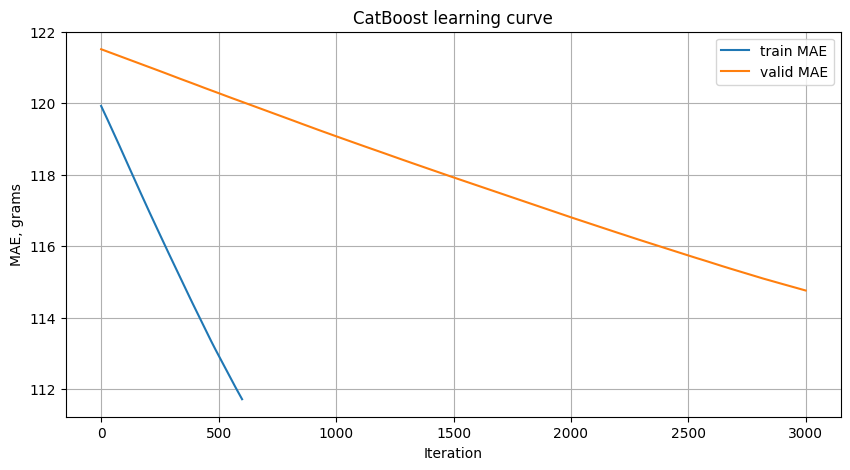

Best iteration: 2999
Best validation score: {'learn': {'MAE': 111.72009874759152}, 'validation': {'MAE': 114.76230258089369}}


In [19]:
import matplotlib.pyplot as plt

evals = model.get_evals_result()

train_metric = evals["learn"]["MAE"]
valid_metric = evals["validation"]["MAE"]

plt.figure(figsize=(10, 5))
plt.plot(train_metric, label="train MAE")
plt.plot(valid_metric, label="valid MAE")
plt.xlabel("Iteration")
plt.ylabel("MAE, grams")
plt.title("CatBoost learning curve")
plt.legend()
plt.grid(True)
plt.show()

print("Best iteration:", model.get_best_iteration())
print("Best validation score:", model.get_best_score())

In [20]:
pred_train = model.predict(train_pool)
pred_valid = model.predict(valid_pool)

print("Train MAE:", mean_absolute_error(y_train, pred_train))
print("Valid MAE:", mean_absolute_error(y_valid, pred_valid))
print("Valid RMSE:", math.sqrt(mean_squared_error(y_valid, pred_valid)))
print("Valid R2:", r2_score(y_valid, pred_valid))

Train MAE: 111.72091398236184
Valid MAE: 114.76243731222775
Valid RMSE: 150.01052337357072
Valid R2: 0.03367114176573072


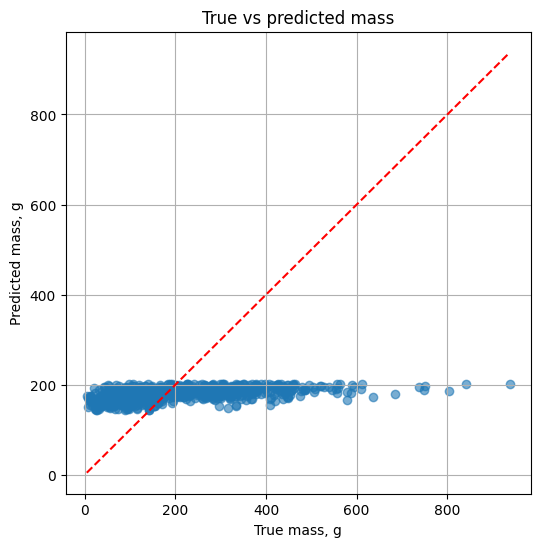

: 

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_valid, pred, alpha=0.6)
lims = [min(y_valid.min(), pred.min()), max(y_valid.max(), pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("True mass, g")
plt.ylabel("Predicted mass, g")
plt.title("True vs predicted mass")
plt.grid(True)
plt.show()